In [1]:
!git clone https://github.com/rasbt/reasoning-from-scratch.git
%cd reasoning-from-scratch
!pip install -r requirements.txt
!pip install sympy antlr4-python3-runtime==4.11.1

fatal: destination path 'reasoning-from-scratch' already exists and is not an empty directory.
/content/reasoning-from-scratch


# GRPO Fine-Tuning

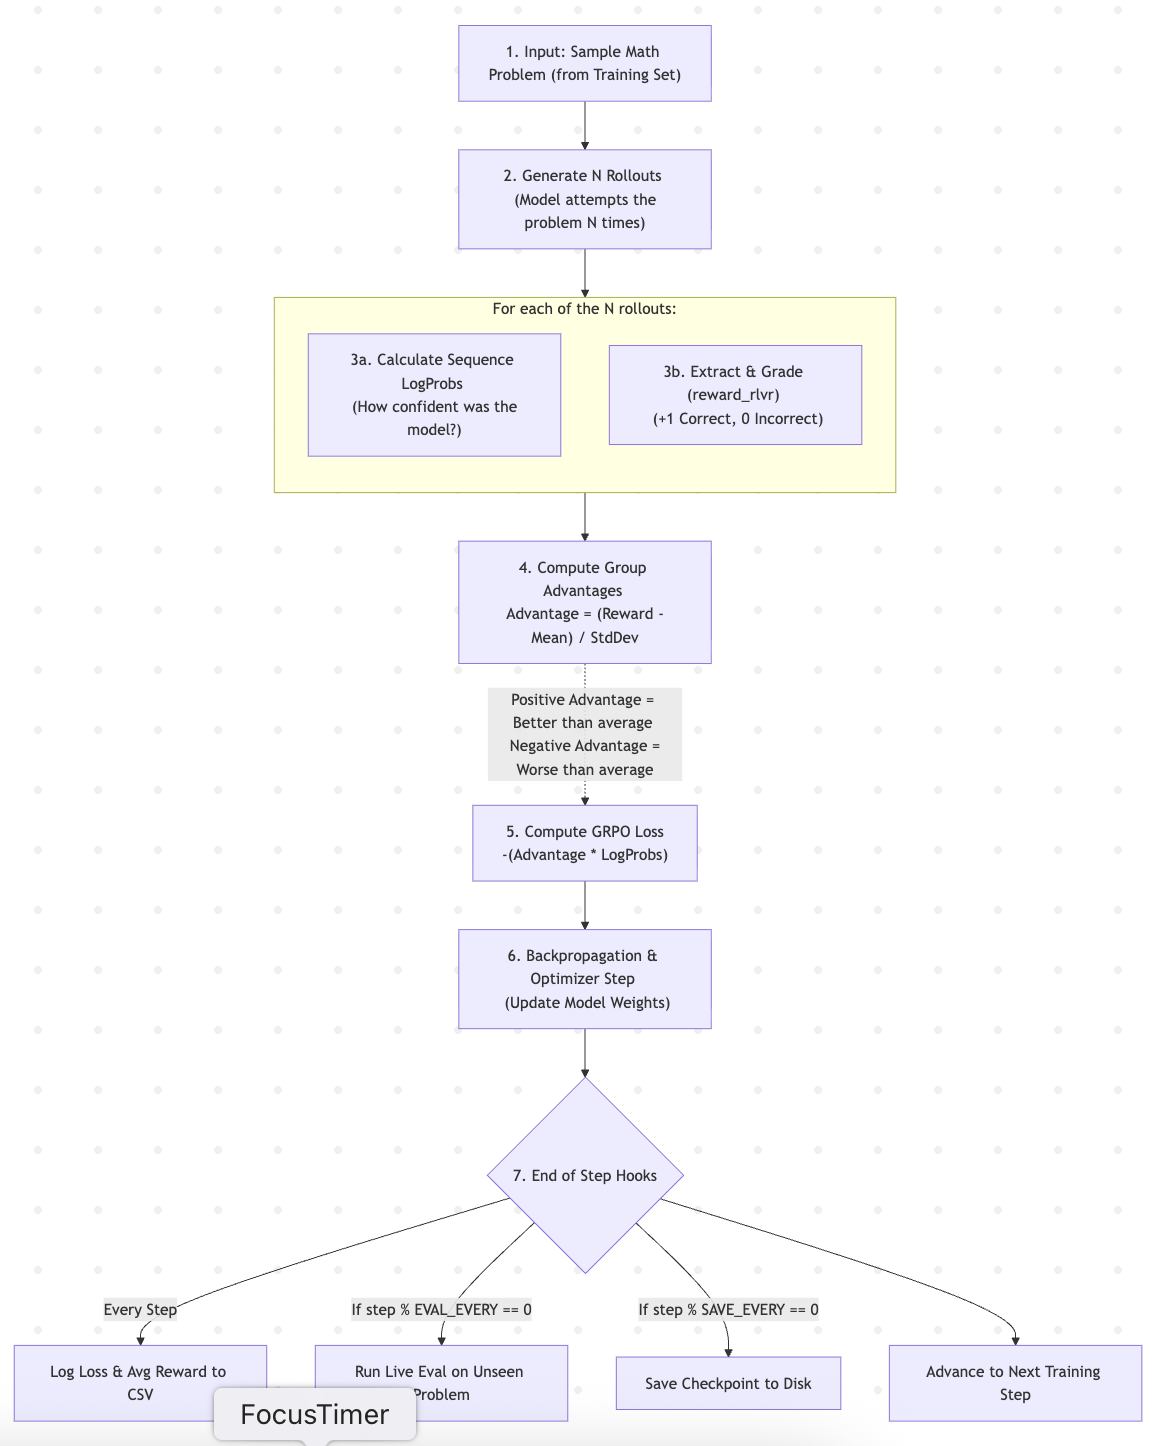

## What this script does
Moves from **inference-time scaling** (Chapters 4–5) to **training-time scaling**:
actually updates the model weights using reinforcement learning so the model gets
better at math permanently, not just per-query.

The algorithm is **GRPO** (Group Relative Policy Optimisation) — the same method
used to train DeepSeek-R1.

---

## Key Concept: How GRPO Differs from Prior Chapters

| | Ch4–5 (Inference Scaling) | Ch6 (GRPO) |
|---|---|---|
| **Model weights** | Frozen | Updated every step |
| **Signal** | Heuristic score / logprob | Binary reward (correct = 1, wrong = 0) |
| **Multiple samples used for** | Voting / selecting best | Estimating advantage |
| **Cost** | Per query | Upfront training cost |

---

## 1. Reward Function (`reward_rlvr`)
Hard binary signal — the only training feedback the model receives.
```
extract answer → normalize_text_hybrid → compare to ground truth
  match   → 1.0
  no match → 0.0
```
No partial credit. No learned reward model. Verifiable correctness only.

---

## 2. Sequence Log-Probability (`sequence_logprob`)
Measures how likely the model was to produce a given trajectory.

**Steps:**
1. Full forward pass → logits → `log_softmax`
2. Shift by 1 (logits[i] predicts token[i+1]) → `[:-1]`
3. `.gather()` picks the log-prob of the actual next token at each position
4. Slice from `prompt_len - 1` to ignore prompt tokens
5. **Sum** (not mean) — the policy gradient theorem needs the log-prob of
   the full sequence, not a per-token average

---

## 3. GRPO Loss (`compute_grpo_loss`)
The core algorithm. Per training example:

```
1. Generate NUM_ROLLOUTS independent trajectories (model in eval/no dropout)
2. Score each with reward_rlvr → binary rewards [0, 1, 1, 0, ...]
3. Advantage = (reward - group_mean) / (group_std + ε)
   → compares each rollout to the GROUP, not a learned value function (≠ PPO)
4. Loss = -mean(advantage × log_prob)
   → positive advantage: push log_prob UP (reinforce)
   → negative advantage: push log_prob DOWN (suppress)
```

> **Why group-relative?** GRPO sidesteps the need for a separate value/critic
> network by using the mean reward of the rollout group as the baseline.
> Simpler and more stable for verifiable tasks.

---

## 4. Trajectory Sampler (`sample_response`)
Standard KV-Cache generation loop with one addition:

- `temperature > 0` → stochastic top-p sampling (used during training rollouts)
- `temperature = 0` → greedy argmax (used during `quick_eval` for determinism)

Returns `(full_token_ids, prompt_len, decoded_text)` — all three needed
downstream for scoring and reward computation.

---

## 5. Training Utilities

| Function | Purpose |
|---|---|
| `log_to_csv` | Appends `step, loss, avg_reward` to `training_metrics.csv` for curve plotting |
| `save_checkpoint` | Saves weights to `checkpoints/grpo_step_N.pth` every EVAL_EVERY steps |
| `quick_eval` | Greedy inference on one held-out MATH-500 problem — live signal of improvement |

---

## 6. Training Loop (`run_ch6_production_training`)

```
Setup: bfloat16 weights, AdamW lr=1e-5, grad clip=1.0

For each step:
  1. ROLLOUT  — compute_grpo_loss() samples NUM_ROLLOUTS trajectories
  2. BACKWARD — loss.backward() + clip_grad_norm + optimizer.step()
  3. LOG      — loss + avg_reward → CSV
  Every EVAL_EVERY steps:
  4. EVAL     — quick_eval() on held-out problem (greedy, deterministic)
  5. SAVE     — checkpoint to disk
```

**Key hyperparameters:**

| Parameter | Value | Why |
|---|---|---|
| `lr` | 1e-5 | Small — fine-tuning, not training from scratch |
| `bfloat16` | ✓ | Halves memory with negligible accuracy loss |
| `clip_grad_norm` | 1.0 | Prevents exploding gradients common in RL |
| `NUM_ROLLOUTS` | 3 | More rollouts = stabler advantage estimates |
| `temperature` (train) | 0.8 | Diverse rollouts needed for meaningful advantage signal |
| `temperature` (eval) | 0.0 | Greedy = deterministic = comparable across checkpoints |

In [2]:
import torch
import time
import requests
import json
from pathlib import Path

# ── Chapter 2 utilities: hardware detection
from reasoning_from_scratch.ch02 import get_device

# ── Qwen3 model components (including KVCache for fast generation)
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B,
    KVCache
)

# ── Chapter 3 utilities: dataset, prompt formatter, answer extractor
from reasoning_from_scratch.ch03 import (
    render_prompt,
    extract_final_candidate,
    load_math500_test
)

# ── Heavy LaTeX normaliser for reward grading
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid

# ── Chapter 4 nucleus filter (reused inside the trajectory sampler)
from reasoning_from_scratch.ch04 import top_p_filter


# ─────────────────────────────────────────────
# 1. DATA & REWARD
# ─────────────────────────────────────────────

def load_math_train():
    """
    Downloads the training split of the MATH dataset (full MATH minus the
    MATH-500 test problems, so there is zero overlap with the eval set).
    Returns a list of {"problem": ..., "answer": ...} dicts.
    """
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "math_full_minus_math500/refs/heads/main/math_full_minus_math500.json"
    )
    return requests.get(url, timeout=30).json()


def reward_rlvr(answer_text, ground_truth):
    """
    Binary RLVR reward function — the training signal that replaces a
    learned reward model.

    Returns:
      1.0  if the extracted answer matches the ground truth after LaTeX
           normalisation (e.g. "\\frac{1}{2}" and "0.5" both become "1/2")
      0.0  if no answer could be extracted, or if it doesn't match.

    This hard 0/1 signal is intentionally simple: the model gets full credit
    for a correct answer and zero for anything else. No partial credit.
    """
    extracted = extract_final_candidate(answer_text, fallback=None)
    if not extracted:
        return 0.0
    return 1.0 if normalize_text_hybrid(extracted) == normalize_text_hybrid(ground_truth) else 0.0


# ─────────────────────────────────────────────
# 2. LOG-PROBABILITY OF A SEQUENCE
# ─────────────────────────────────────────────

def sequence_logprob(model, token_ids, prompt_len):
    """
    Computes the sum of log-probabilities of the answer tokens only
    (i.e. everything after the prompt).

    Used inside compute_grpo_loss to measure how likely the model was to
    produce each rollout trajectory — this is the "policy log-prob" term
    in the GRPO gradient update.

    Mechanism:
      1. Run a full forward pass to get logits for every position.
      2. Apply log_softmax to convert to log-probabilities.
      3. Shift by 1: logits[i] predicts token[i+1], so we slice [:-1].
      4. Use .gather() to pick the log-prob of the actual next token at
         each position (indexing into the vocab dimension).
      5. Slice from prompt_len-1 onward to ignore prompt tokens —
         we only want the log-prob of what the model *generated*.
      6. Return the sum (not mean) across answer tokens.

    Why sum, not mean? GRPO weights each trajectory by its advantage.
    Summing log-probs gives the log-probability of the full sequence,
    which is what the policy gradient theorem operates on.
    """
    # Forward pass — cast to float32 for numerical stability
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()  # (seq_len, vocab_size)

    # log_softmax → log-probs; [:-1] aligns with next-token targets
    log_probs = torch.log_softmax(logits, dim=-1)[:-1]         # (seq_len-1, vocab_size)

    # For each position, pick the log-prob of the token that actually came next
    answer_logps = log_probs.gather(1, token_ids[1:].unsqueeze(-1)).squeeze(-1)
    # (seq_len-1,)

    # Sum only the answer tokens (causal offset: prompt ends at prompt_len-1)
    return torch.sum(answer_logps[prompt_len - 1:])


# ─────────────────────────────────────────────
# 3. TRAJECTORY SAMPLER
# ─────────────────────────────────────────────

@torch.no_grad()
def sample_response(
    model, tokenizer, prompt, device,
    max_new_tokens=256, temperature=0.8, top_p=0.9
):
    """
    Generates one complete response (a "trajectory" in RL terminology) using
    the KV-Cache for efficiency.

    Called inside compute_grpo_loss to produce the NUM_ROLLOUTS independent
    trajectories that GRPO needs to estimate an advantage for each one.

    temperature=0.0 → greedy argmax (deterministic; used during live eval).
    temperature>0.0 → stochastic top-p sampling (used during training rollouts).

    Returns:
        full_token_ids : (prompt_len + generated_len,) tensor — needed by
                         sequence_logprob to score the whole trajectory.
        prompt_len     : int — where the prompt ends in full_token_ids.
        decoded_text   : str — the generated answer text for reward_rlvr.
    """
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Prefill: process the prompt once to populate the KV-Cache
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    logits = model(input_ids.unsqueeze(0), cache=cache)[:, -1]

    generated = []

    for _ in range(max_new_tokens):
        if temperature > 0.0:
            # Stochastic path: scale → softmax → nucleus filter → sample
            probas     = top_p_filter(torch.softmax(logits / temperature, dim=-1), top_p)
            next_token = torch.multinomial(probas, num_samples=1)
        else:
            # Deterministic path: greedy argmax (temperature=0 avoids div-by-zero)
            next_token = torch.argmax(logits, dim=-1, keepdim=True)

        if tokenizer.eos_token_id is not None and next_token.item() == tokenizer.eos_token_id:
            break

        generated.append(next_token.item())

        # Feed only the new token; cache supplies all prior context
        logits = model(next_token, cache=cache)[:, -1]

    # Concatenate prompt + generated tokens for sequence_logprob scoring
    full_token_ids = torch.cat([
        input_ids,
        torch.tensor(generated, device=device, dtype=input_ids.dtype)
    ])

    return full_token_ids, input_ids.numel(), tokenizer.decode(generated)


# ─────────────────────────────────────────────
# 4. GRPO LOSS
# ─────────────────────────────────────────────

def compute_grpo_loss(model, tokenizer, example, device, num_rollouts=4):
    """
    Computes the GRPO (Group Relative Policy Optimisation) loss for one
    training example.

    GRPO overview:
      Instead of a learned reward model, GRPO uses a verifiable reward
      function (reward_rlvr) and estimates advantages by comparing each
      rollout's reward to the GROUP MEAN of all rollouts for the same
      question. This is the key difference from PPO, which compares against
      a value-function baseline.

    Steps:
      1. Generate NUM_ROLLOUTS independent trajectories (model is in eval
         mode during sampling so dropout is off, but gradients are needed
         for the log-prob computation that follows).
      2. Score each trajectory with reward_rlvr → binary 0 or 1.
      3. Compute advantage = (reward - group_mean) / (group_std + ε).
         A rollout that got reward=1 when the mean was 0.5 gets advantage=+1;
         one that got reward=0 gets advantage=-1. This normalisation keeps
         the gradient scale stable regardless of absolute reward values.
      4. Policy gradient loss = -mean(advantage × log_prob).
         Positive advantage → push log_prob UP (reinforce good trajectories).
         Negative advantage → push log_prob DOWN (suppress bad ones).

    Returns:
        pg_loss    : scalar tensor — backpropagate this.
        roll_rewards : list of floats — logged for monitoring.
    """
    roll_logps, roll_rewards = [], []
    prompt = render_prompt(example["problem"])

    # Switch to eval for sampling (no dropout), then restore training mode
    was_training = model.training
    model.eval()

    for _ in range(num_rollouts):
        token_ids, prompt_len, text = sample_response(model, tokenizer, prompt, device)
        roll_logps.append(sequence_logprob(model, token_ids, prompt_len))
        roll_rewards.append(reward_rlvr(text, example["answer"]))

    if was_training:
        model.train()

    # Advantage normalisation across the group of rollouts
    rewards    = torch.tensor(roll_rewards, device=device)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    # Policy gradient: detach advantages (they are targets, not part of the graph)
    pg_loss = -(advantages.detach() * torch.stack(roll_logps)).mean()

    return pg_loss, roll_rewards


# ─────────────────────────────────────────────
# 5. TRAINING UTILITIES
# ─────────────────────────────────────────────

def save_checkpoint(model, step_num):
    """
    Saves model weights to checkpoints/grpo_step_{N}.pth.
    Called every EVAL_EVERY steps so training can be resumed if it crashes.
    """
    out_dir = Path("checkpoints")
    out_dir.mkdir(exist_ok=True)
    file_path = out_dir / f"grpo_step_{step_num}.pth"
    torch.save(model.state_dict(), file_path)
    print(f"💾 Checkpoint saved to: {file_path}")


def log_to_csv(step, loss, avg_reward):
    """
    Appends one row (step, loss, avg_reward) to training_metrics.csv.
    Creates the file with a header row on the first call.
    Useful for plotting training curves after the run.
    """
    log_file = Path("training_metrics.csv")
    if not log_file.exists():
        log_file.write_text("step,loss,avg_reward\n", encoding="utf-8")
    with log_file.open("a", encoding="utf-8") as f:
        f.write(f"{step},{loss:.4f},{avg_reward:.4f}\n")


def quick_eval(model, tokenizer, device, test_example):
    """
    Runs a single greedy (temperature=0) inference pass on one held-out
    MATH-500 problem to give a live signal of whether the model is improving.

    Uses temperature=0 for determinism — the same question always produces
    the same answer, so improvement over steps is meaningful.

    Temporarily switches the model to eval mode and restores training mode
    afterward so the training loop is unaffected.
    """
    print(f"\n   🧪 [Live Eval] Testing unseen problem: {test_example['problem'][:30]}...")

    was_training = model.training
    model.eval()

    # Greedy decode — deterministic so results are comparable across checkpoints
    _, _, text = sample_response(
        model, tokenizer,
        render_prompt(test_example["problem"]),
        device,
        temperature=0.0   # Greedy; safe because sample_response handles the 0-case explicitly
    )

    extracted  = extract_final_candidate(text)
    is_correct = reward_rlvr(text, test_example["answer"]) > 0

    print(f"   🧪 [Live Eval] Result: {'✅ Passed' if is_correct else '❌ Failed'} (Extracted: {extracted!r})")

    if was_training:
        model.train()


# ─────────────────────────────────────────────
# 6. PRODUCTION TRAINING LOOP
# ─────────────────────────────────────────────

def run_ch6_production_training():
    """
    Full GRPO fine-tuning loop.

    Training setup:
      - Optimiser : AdamW, lr=1e-5 (small — we're fine-tuning, not training from scratch)
      - Precision  : bfloat16 (halves memory, negligible accuracy loss on modern GPUs)
      - Grad clip  : 1.0 (prevents exploding gradients common in RL training)
      - One example per step (online RL — the model trains on its own fresh rollouts)

    Per step:
      1. Sample NUM_ROLLOUTS trajectories for the current training problem.
      2. Compute GRPO loss (advantage-weighted policy gradient).
      3. Backpropagate, clip gradients, step the optimiser.
      4. Every EVAL_EVERY steps: run quick_eval on a held-out problem
         and save a checkpoint.
    """

    # ── Hardware & model setup ────────────────────────────────────────────
    device = get_device()
    print(f"Using device: {device}")

    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")

    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.to(torch.bfloat16)  # Reduce memory footprint before loading weights
    model.load_state_dict(
        torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device, weights_only=True)
    )
    model.to(device)

    # ── Data ──────────────────────────────────────────────────────────────
    math_train_data = load_math_train()    # Training problems (no MATH-500 overlap)
    math_eval_data  = load_math500_test()  # Held-out problems for quick_eval

    # ── Hyperparameters ───────────────────────────────────────────────────
    STEPS        = 100   # Total gradient update steps
    NUM_ROLLOUTS = 3     # Trajectories per step — more = stabler advantage estimates
    EVAL_EVERY   = 5     # Steps between live eval + checkpoint

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
    model.train()

    print(f"\nStarting GRPO Training for {STEPS} steps...")

    for step in range(1, STEPS + 1):
        train_example = math_train_data[step]
        print(f"\n[Step {step}] Training on: {train_example['problem'][:50]}...")

        # Forward + backward
        optimizer.zero_grad()
        loss, rewards = compute_grpo_loss(
            model, tokenizer, train_example, device, num_rollouts=NUM_ROLLOUTS
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        torch.cuda.empty_cache()  # Free any fragmented GPU memory after each step

        avg_reward = sum(rewards) / len(rewards)
        print(f"   📈 Loss: {loss.item():.4f} | Avg Reward: {avg_reward:.2f}")
        log_to_csv(step, loss.item(), avg_reward)

        # Periodic eval + checkpoint
        if step % EVAL_EVERY == 0:
            quick_eval(model, tokenizer, device, math_eval_data[step])
            save_checkpoint(model, step)

    print(
        "\nTraining complete! "
        "Check your Colab file explorer for 'training_metrics.csv' and the 'checkpoints' folder."
    )


# ── Entry point ────────────────────────────────────────────────────────────────
run_ch6_production_training()

Using NVIDIA CUDA GPU
Using device: cuda
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)

Starting GRPO Training for 100 steps...

[Step 1] Training on: A rectangular band formation is a formation with $...
   📈 Loss: -0.0000 | Avg Reward: 0.00

[Step 2] Training on: What is the degree of the polynomial $(4 +5x^3 +10...
   📈 Loss: -0.0000 | Avg Reward: 0.00

[Step 3] Training on: Evaluate $\left\lceil3\left(6-\frac12\right)\right...
   📈 Loss: -0.0000 | Avg Reward: 0.00

[Step 4] Training on: Sam is hired for a 20-day period. On days that he ...
   📈 Loss: -0.0000 | Avg Reward: 0.00

[Step 5] Training on: Find the center of the circle with equation $x^2 -...
   📈 Loss: -0.0000 | Avg Reward: 0.00

   🧪 [Live Eval] Testing unseen problem: A regular hexagon can be divid...
   🧪 [Live Eval] Result: ❌ Failed (Extracted: '126')
💾 Checkpoint saved to: checkpoints/grpo_step_5.pth

[Step 6] Training on: What are all values of $p$ such that for every $q>...
   📈 Loss: -0.0000 | Avg Reward: 0.00


KeyboardInterrupt: 

In [4]:
import torch
from pathlib import Path

# ── Chapter 2 utilities: hardware detection
from reasoning_from_scratch.ch02 import get_device

# ── Qwen3 model components (KVCache for fast generation)
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B,
    KVCache
)

# ── Chapter 3 utilities: prompt formatter, answer extractor, eval dataset
from reasoning_from_scratch.ch03 import (
    render_prompt,
    extract_final_candidate,
    load_math500_test
)

# ── Heavy LaTeX normaliser for grading
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid


# ─────────────────────────────────────────────
# 1. DETERMINISTIC GENERATION
# ─────────────────────────────────────────────

@torch.no_grad()
def generate_greedy(model, tokenizer, prompt, device, max_new_tokens=256):
    """
    Generates a response using greedy decoding (argmax at every step) —
    no temperature, no sampling, no randomness.

    Used here instead of the Chapter 4 stochastic sampler because we are
    evaluating a trained checkpoint, not generating diverse rollouts.
    Greedy decoding is deterministic: the same prompt always produces the
    same output, so results are directly comparable across checkpoints.

    Uses the KV-Cache for efficiency — identical to Chapter 2's generation
    loop, just without any sampling logic.
    """
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Prefill: process the full prompt once to populate the KV-Cache
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    logits = model(input_ids.unsqueeze(0), cache=cache)[:, -1]

    generated = []

    for _ in range(max_new_tokens):
        # Greedy: always pick the single highest-logit token
        next_token = torch.argmax(logits, dim=-1, keepdim=True)

        if tokenizer.eos_token_id is not None and next_token.item() == tokenizer.eos_token_id:
            break  # Stop when the model signals end of sequence

        generated.append(next_token.item())

        # Feed only the new token; KV-Cache supplies all prior context
        logits = model(next_token, cache=cache)[:, -1]

    return tokenizer.decode(generated)


# ─────────────────────────────────────────────
# 2. CHECKPOINT EVALUATION ENGINE
# ─────────────────────────────────────────────

def evaluate_latest_checkpoint(dataset_size=5):
    """
    Loads the most recent healthy GRPO checkpoint and evaluates it on
    held-out MATH-500 problems.

    The "bulletproof loading" pattern exists because GRPO training saves
    checkpoints periodically, and the most recent one can be corrupted if
    the session crashed mid-save. Rather than failing hard, this function
    walks backward through all checkpoints (newest → oldest) until it
    finds one that loads cleanly.

    Evaluation uses greedy decoding (deterministic) so accuracy numbers
    are directly comparable between checkpoints and between runs.
    """

    device = get_device()
    print(f"Using device: {device}")

    # ── Step 1: Discover all saved checkpoints ─────────────────────────────
    checkpoint_dir = Path("checkpoints")
    if not checkpoint_dir.exists():
        raise FileNotFoundError(
            "No 'checkpoints' directory found. Please run the training loop first."
        )

    checkpoints = list(checkpoint_dir.glob("grpo_step_*.pth"))
    if not checkpoints:
        raise FileNotFoundError("No .pth files found in the 'checkpoints' directory.")

    # Sort newest → oldest by extracting the step number from the filename
    # e.g. "grpo_step_95.pth" → 95
    checkpoints_sorted = sorted(
        checkpoints,
        key=lambda p: int(p.stem.split("_")[-1]),
        reverse=True   # Highest step number first
    )

    # ── Step 2: Build the model architecture (no weights yet) ─────────────
    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")
    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.to(torch.bfloat16)  # Match the precision used during GRPO training

    # ── Step 3: Bulletproof checkpoint loading ─────────────────────────────
    # Walk newest → oldest; load the first checkpoint that doesn't raise
    # a RuntimeError. A corrupted file (from a mid-save crash) will fail
    # load_state_dict with a RuntimeError — we catch it and try the next one.
    loaded_successfully = False

    for ckpt in checkpoints_sorted:
        print(f"\nAttempting to load weights from: {ckpt.name}...")
        try:
            model.load_state_dict(
                torch.load(ckpt, map_location=device, weights_only=True)
            )
            print("✅ Successfully loaded weights! This checkpoint is healthy.")
            loaded_successfully = True
            break  # Found a good checkpoint — stop searching
        except RuntimeError:
            # File is corrupted (likely truncated by a crash during torch.save)
            print(f"❌ WARNING: {ckpt.name} is corrupted. Skipping...")
            # Uncomment the line below to automatically delete corrupted files:
            # ckpt.unlink()

    if not loaded_successfully:
        raise RuntimeError(
            "🚨 All available checkpoints are corrupted! "
            "You will need to rerun the Chapter 6 training loop."
        )

    model.to(device).eval()

    # ── Step 4: Load held-out evaluation data ─────────────────────────────
    # MATH-500 was excluded from the training set in Chapter 6, so these
    # problems are genuinely unseen by the fine-tuned model.
    math_eval_data = load_math500_test()
    if dataset_size is not None:
        math_eval_data = math_eval_data[:dataset_size]

    num_correct = 0
    print(f"\nStarting Evaluation on {len(math_eval_data)} unseen questions...")

    # ── Step 5: Evaluate ───────────────────────────────────────────────────
    for i, row in enumerate(math_eval_data, 1):
        prompt = render_prompt(row["problem"])

        # Generate a deterministic response and extract the answer candidate
        answer_text = generate_greedy(model, tokenizer, prompt, device)
        extracted   = extract_final_candidate(answer_text)

        # Normalise both sides with the hybrid LaTeX parser before comparing
        # so that "\\frac{1}{2}" and "0.5" both resolve to the same string
        pred       = normalize_text_hybrid(extracted)
        gold       = normalize_text_hybrid(row["answer"])
        is_correct = (pred == gold)
        num_correct += int(is_correct)

        print(f"\n--- Question {i} ---")
        print(f"Expected : {row['answer']}")
        print(f"Extracted: {extracted!r}")
        print(f"Graded   : {'CORRECT ✅' if is_correct else 'INCORRECT ❌'}")

    accuracy = (num_correct / len(math_eval_data)) * 100
    print(f"\nFinal Checkpoint Accuracy: {num_correct}/{len(math_eval_data)} ({accuracy:.1f}%)")


# ── Entry point ────────────────────────────────────────────────────────────────
evaluate_latest_checkpoint(dataset_size=50)

Using NVIDIA CUDA GPU
Using device: cuda
✓ qwen3/qwen3-0.6B-base.pth already up-to-date

Attempting to load weights from: grpo_step_55.pth...
❌ WARNING: grpo_step_55.pth is corrupted (likely from a previous crash). Skipping...

Attempting to load weights from: grpo_step_50.pth...
✅ Successfully loaded weights! This checkpoint is healthy.

Starting Evaluation on 50 unseen questions...

--- Question 1 ---
Expected : \left( 3, \frac{\pi}{2} \right)
Extracted: '\\left(3, \\frac{\\pi}{2}\\right)'
Graded   : CORRECT ✅

--- Question 2 ---
Expected : p - q
Extracted: '2'
Graded   : INCORRECT ❌

--- Question 3 ---
Expected : \frac{14}{3}
Extracted: '1'
Graded   : INCORRECT ❌

--- Question 4 ---
Expected : 9
Extracted: '9'
Graded   : CORRECT ✅

--- Question 5 ---
Expected : \text{Evelyn}
Extracted: '3.6'
Graded   : INCORRECT ❌

--- Question 6 ---
Expected : 42
Extracted: '42'
Graded   : CORRECT ✅

--- Question 7 ---
Expected : 27
Extracted: '4'
Graded   : INCORRECT ❌

--- Question 8 ---
Expected